In [1]:
import seaborn as sns
import pandas as pd
import glob
import os
from collections import defaultdict

In [2]:
data_path = "/home/nmsec/Documents/Weak_link_figures/data"
out_path = "/home/nmsec/Documents/Weak_link_figures/Output"

In [3]:
df = pd.read_csv(f'{out_path}/dual_vpn_protocols_global.csv')

In [4]:
unique_pairs_df = df.groupby(["protocol", "censys_protocol"])["count"].sum().reset_index()
unique_pairs_df

,protocol,censys_protocol,count
0,Nordwhisper,IKEv1,53
1,Nordwhisper,IKEv2,7244
2,OpenVPN,IKEv1,941
3,OpenVPN,IKEv2,8488
4,OpenVPN,L2TP,159
5,OpenVPN,PPTP,166
6,Shadowsocks,IKEv1,9
7,Shadowsocks,IKEv2,495
8,Shadowsocks,L2TP,160
9,Shadowsocks,OpenVPN,392


In [5]:
# history: total unique scanned servers per strong protocol (globally deduplicated)
# vulnerable: subset of those that have any Censys-detectable protocol
counts_df   = pd.read_csv(f'{out_path}/protocol_global_counts.csv')
visible_df  = pd.read_csv(f'{out_path}/protocol_global_visible_counts.csv')

protocol_rename = {
    'wireguard':   'WireGuard',
    'openvpn':     'OpenVPN',
    'shadowsocks': 'ShadowSocks',
    'nordwhisper': 'Nordwhisper',
    'xray':        'Xray',
}

history    = counts_df.set_index('protocol')['count'].rename(index=protocol_rename).to_dict()
vulnerable = visible_df.set_index('protocol')['count'].rename(index=protocol_rename).to_dict()

print('Protocol | scanned | exposed')
for p in sorted(history):
    v = vulnerable.get(p, 0)
    t = history[p]
    print(f'  {p}: {v}/{t} ({v/t*100:.1f}%)')


Protocol | scanned | exposed
  Nordwhisper: 7297/7300 (100.0%)
  OpenVPN: 8558/10294 (83.1%)
  ShadowSocks: 560/827 (67.7%)
  WireGuard: 22350/23928 (93.4%)
  Xray: 184/617 (29.8%)


/tmp/ipykernel_801348/601081056.py:57: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = heatmap_data.applymap(lambda x: f"{int(x):,}")


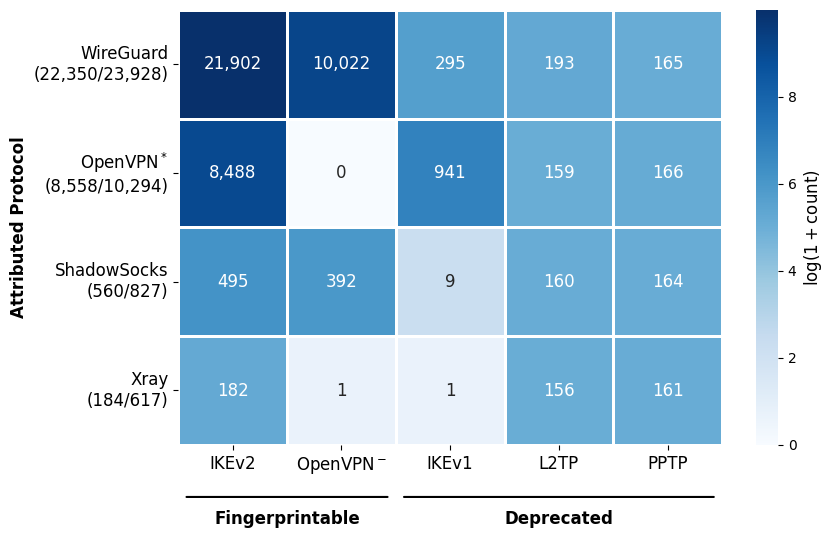

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- 1. Data Filtering & Pivot ---
filter_condition = (unique_pairs_df['protocol'] != 'openvpn, wireguard') & \
                   (unique_pairs_df['protocol'] != 'xray') & \
                   (unique_pairs_df['protocol'] != 'Nordwhisper')
filtered_unique_pairs_df = unique_pairs_df[filter_condition]

heatmap_data = filtered_unique_pairs_df.pivot_table(
    index='protocol',
    columns='censys_protocol',
    values='count'
).fillna(0)

# --- 2. Fix Case-Sensitivity & Normalization ---
heatmap_data.index = heatmap_data.index.str.lower()
rename_map = {
    'wireguard': 'WireGuard',
    'openvpn': 'OpenVPN',
    'shadowsocks': 'ShadowSocks',
    'xray': 'Xray'
}
heatmap_data = heatmap_data.rename(index=rename_map)

desired_col_order = ['IKEv2', 'OpenVPN', 'IKEv1', 'L2TP', 'PPTP']
desired_row_order = ['WireGuard', 'OpenVPN', 'ShadowSocks', 'Xray']

# Reindex to force the specific order
heatmap_data = heatmap_data.reindex(index=desired_row_order, columns=desired_col_order).fillna(0)

# --- 3. Label Preparation (Fontsize 12) ---
#y_labels = [
#    f"OpenVPN$^*$\n({vulnerable.get(row, 0)}/{history.get(row, 0)})"
#    if row == "OpenVPN"
#    else f"{row}\n({vulnerable.get(row, 0)}/{history.get(row, 0)})"
#    for row in desired_row_order
#]

y_labels = [
    f"OpenVPN$^*$\n({vulnerable.get(row, 0):,}/{history.get(row, 0):,})"
    if row == "OpenVPN"
    else f"{row}\n({vulnerable.get(row, 0):,}/{history.get(row, 0):,})"
    for row in desired_row_order
]

x_labels = [
    r"OpenVPN$^-$" if col == "OpenVPN" else col
    for col in desired_col_order
]

# --- 4. Processing & Plotting ---
heatmap_data_log = np.log1p(heatmap_data)
#annot = heatmap_data.astype(int).astype(str)
annot = heatmap_data.applymap(lambda x: f"{int(x):,}")

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    heatmap_data_log,
    annot=annot,
    fmt="",
    cmap="Blues",
    linewidths=1.0,
    linecolor="white",
    square=True,
    annot_kws={"size": 12},
    cbar_kws={"label": r"$\log(1 + \mathrm{count})$"},
    vmin=0,
    ax=ax
)

# --- Fontsize 12 Global Settings ---
ax.figure.axes[-1].yaxis.label.set_size(12)

ax.set_xlabel("", fontsize=12)
ax.set_ylabel("Attributed Protocol", fontsize=12, fontweight='bold')

ax.set_yticklabels(y_labels, rotation=0, ha="right", rotation_mode="anchor", fontsize=12)
ax.set_xticklabels(x_labels, rotation=0, fontsize=12)

# --- 5. Grouping Brackets ---
trans = ax.get_xaxis_transform()

ax.annotate('', xy=(0.05, -0.12), xycoords=trans, xytext=(1.95, -0.12),
            arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
ax.text(1, -0.15, "Fingerprintable", transform=trans,
        ha='center', va='top', fontsize=12, fontweight='bold')

ax.annotate('', xy=(2.05, -0.12), xycoords=trans, xytext=(4.95, -0.12),
            arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
ax.text(3.5, -0.15, "Deprecated", transform=trans,
        ha='center', va='top', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.25, left=0.3)

plt.savefig(f"{out_path}/heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_801348/1621605913.py:52: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = heatmap_data.applymap(lambda x: f"{int(x):,}")


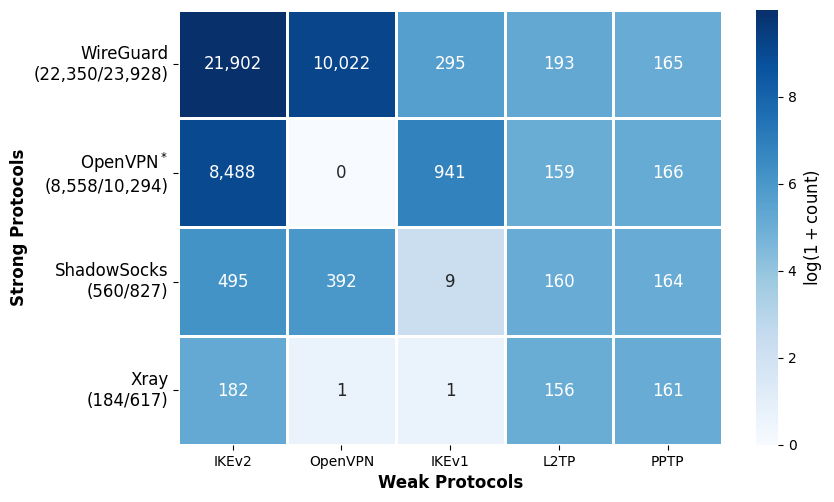

In [10]:
# --- 1. Data Filtering & Pivot ---
filter_condition = (unique_pairs_df['protocol'] != 'openvpn, wireguard') & \
                   (unique_pairs_df['protocol'] != 'xray') & \
                   (unique_pairs_df['protocol'] != 'Nordwhisper')
filtered_unique_pairs_df = unique_pairs_df[filter_condition]

heatmap_data = filtered_unique_pairs_df.pivot_table(
    index='protocol',
    columns='censys_protocol',
    values='count'
).fillna(0)

# --- 2. Fix Case-Sensitivity & Normalization ---
heatmap_data.index = heatmap_data.index.str.lower()
rename_map = {
    'wireguard': 'WireGuard',
    'openvpn': 'OpenVPN',
    'shadowsocks': 'ShadowSocks',
    'xray': 'Xray'
}
heatmap_data = heatmap_data.rename(index=rename_map)

desired_col_order = ['IKEv2', 'OpenVPN', 'IKEv1', 'L2TP', 'PPTP']
desired_row_order = ['WireGuard', 'OpenVPN', 'ShadowSocks', 'Xray']

# Reindex to force the specific order
heatmap_data = heatmap_data.reindex(index=desired_row_order, columns=desired_col_order).fillna(0)

# --- 3. Label Preparation (Fontsize 12) ---
#y_labels = [
#    f"OpenVPN$^*$\n({vulnerable.get(row, 0)}/{history.get(row, 0)})"
#    if row == "OpenVPN"
#    else f"{row}\n({vulnerable.get(row, 0)}/{history.get(row, 0)})"
#    for row in desired_row_order
#]

y_labels = [
    f"OpenVPN$^*$\n({vulnerable.get(row, 0):,}/{history.get(row, 0):,})"
    if row == "OpenVPN"
    else f"{row}\n({vulnerable.get(row, 0):,}/{history.get(row, 0):,})"
    for row in desired_row_order
]

x_labels = [
    r"OpenVPN$^\textbf{--}$" if col == "OpenVPN" else col
    for col in desired_col_order
]

# --- 4. Processing & Plotting ---
heatmap_data_log = np.log1p(heatmap_data)
#annot = heatmap_data.astype(int).astype(str)
annot = heatmap_data.applymap(lambda x: f"{int(x):,}")

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    heatmap_data_log,
    annot=annot,
    fmt="",
    cmap="Blues",
    linewidths=1.0,
    linecolor="white",
    square=True,
    annot_kws={"size": 12},
    cbar_kws={"label": r"$\log(1 + \mathrm{count})$"},
    vmin=0,
    ax=ax
)

# --- Fontsize 12 Global Settings ---
ax.figure.axes[-1].yaxis.label.set_size(12)

ax.set_xlabel("Weak Protocols", fontsize=12, fontweight='bold')
ax.set_ylabel("Strong Protocols", fontsize=12, fontweight='bold')

ax.set_yticklabels(y_labels, rotation=0, ha="right", rotation_mode="anchor", fontsize=12)
#ax.set_xticklabels(x_labels, rotation=0, fontsize=12)

# --- 5. Grouping Brackets ---
trans = ax.get_xaxis_transform()

#ax.annotate('', xy=(0.05, -0.12), xycoords=trans, xytext=(1.95, -0.12),
#            arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
#        ha='center', va='top', fontsize=12, fontweight='bold')

#ax.annotate('', xy=(2.05, -0.12), xycoords=trans, xytext=(4.95, -0.12),
#            arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
#ax.text(3.5, -0.15, "Deprecated", transform=trans,
#        ha='center', va='top', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.25, left=0.3)

plt.savefig(f"{out_path}/heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()